In [1]:
import pandas as pd

c:\Users\Rutvik\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

c:\Users\Rutvik\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
data = pd.read_csv('C:\imp stuff\Customer_Churn.csv')

In [4]:
print(data.shape)
print(data.dtypes)

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
#checking for null values per column
print(data.isnull().sum())
print(f"\nTotal nulls: {data.isnull().sum().sum()}")

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total nulls: 0


In [7]:
data.duplicated().sum() #duplicate values

0

In [8]:
#total charges is coded as string but has numbers so checking for blank spaces
print(data[data['TotalCharges'].str.strip() == '']['TotalCharges'])

488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object


In [9]:
#converting them into numeric type and returning null if it has a blank space
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [10]:
print(data.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
#filling null values with median values
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

C:\Users\Rutvik\AppData\Local\Temp\ipykernel_60016\1078680315.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


In [12]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [13]:
clean_data=data.copy()

In [14]:
clean_data=clean_data.drop('customerID', axis=1)

In [15]:
clean_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in cols:
    clean_data[col] = clean_data[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })


In [17]:
clean_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
#converting the target variable to binary
clean_data['Churn'] = clean_data['Churn'].map({'Yes': 1, 'No': 0})

Churn Rate: 26.5%
Retention Rate: 73.5%


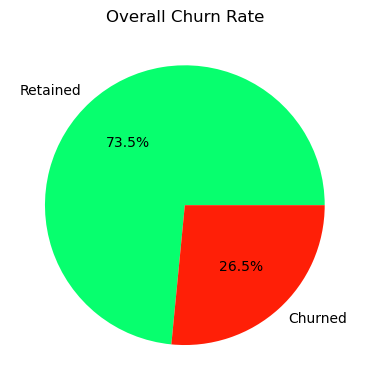

In [19]:
#EDA

churn_rate = clean_data['Churn'].value_counts(normalize=True) * 100
print(f"Churn Rate: {churn_rate[1]:.1f}%")
print(f"Retention Rate: {churn_rate[0]:.1f}%")

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(churn_rate, labels=['Retained', 'Churned'],
       autopct='%1.1f%%', colors=["#07ff6e", "#ff1f07"])
ax.set_title('Overall Churn Rate')
plt.tight_layout()
plt.show()

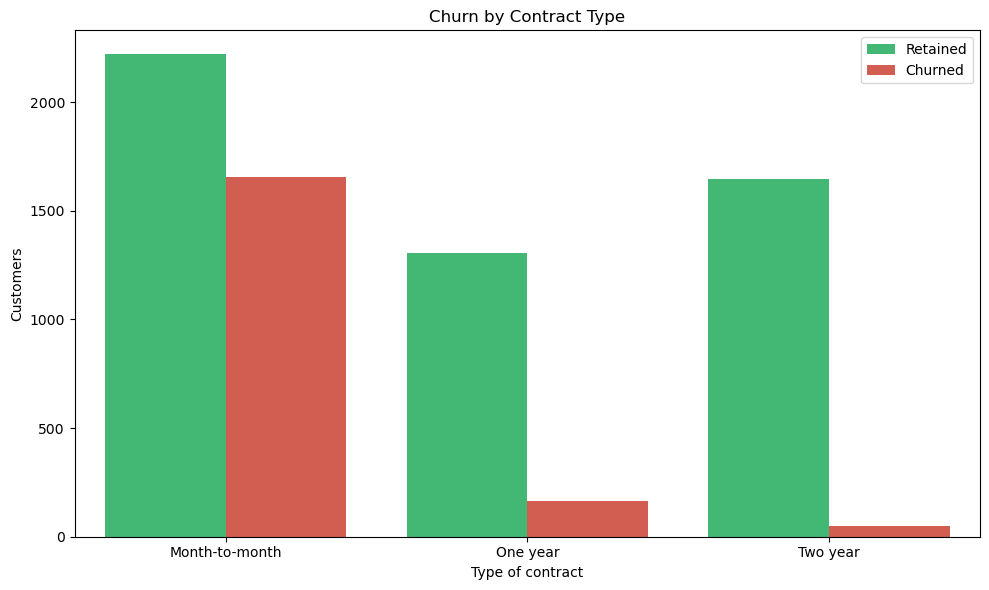

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=clean_data, x='Contract', hue='Churn',
              palette={0: '#2ecc71', 1: '#e74c3c'})
plt.title('Churn by Contract Type')
plt.xlabel('Type of contract')
plt.ylabel('Customers')
plt.legend(labels=['Retained', 'Churned'])
plt.tight_layout()
plt.show()


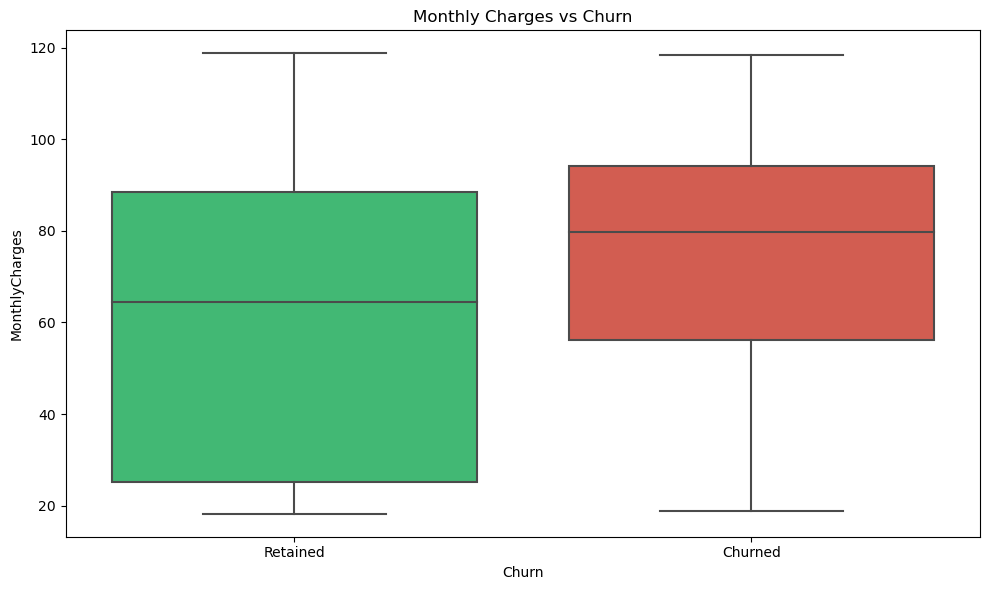

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=clean_data, x='Churn', y='MonthlyCharges',
            palette={0: '#2ecc71', 1: '#e74c3c'})
plt.title('Monthly Charges vs Churn')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.tight_layout()
plt.show()

c:\Users\Rutvik\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Rutvik\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Rutvik\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Rutvik\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a

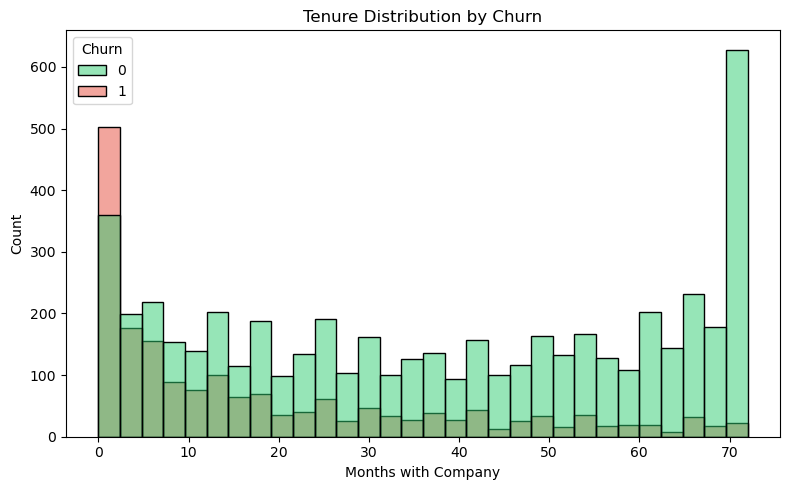

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(data=clean_data, x='tenure', hue='Churn',
             bins=30, palette={0: '#2ecc71', 1: '#e74c3c'})
plt.title('Tenure Distribution by Churn')
plt.xlabel('Months with Company')
plt.tight_layout()
plt.show()

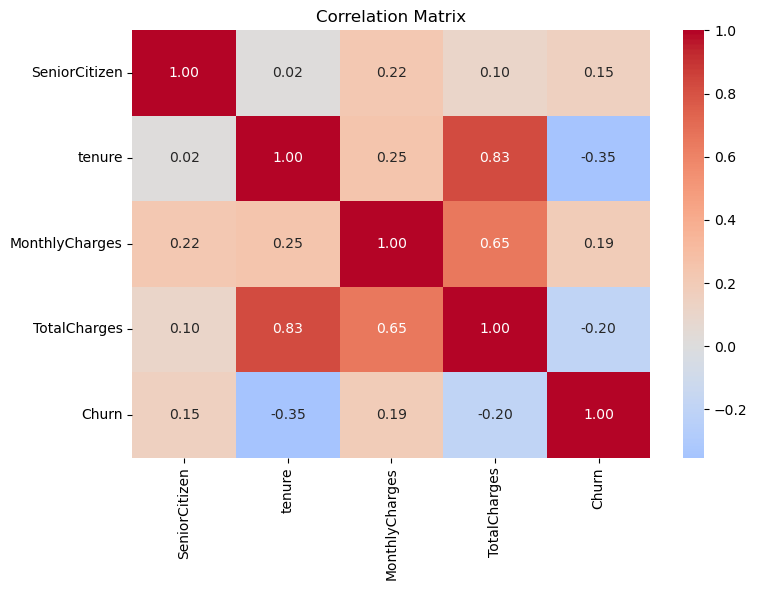

In [23]:
plt.figure(figsize=(8, 6))
numeric_df = clean_data.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

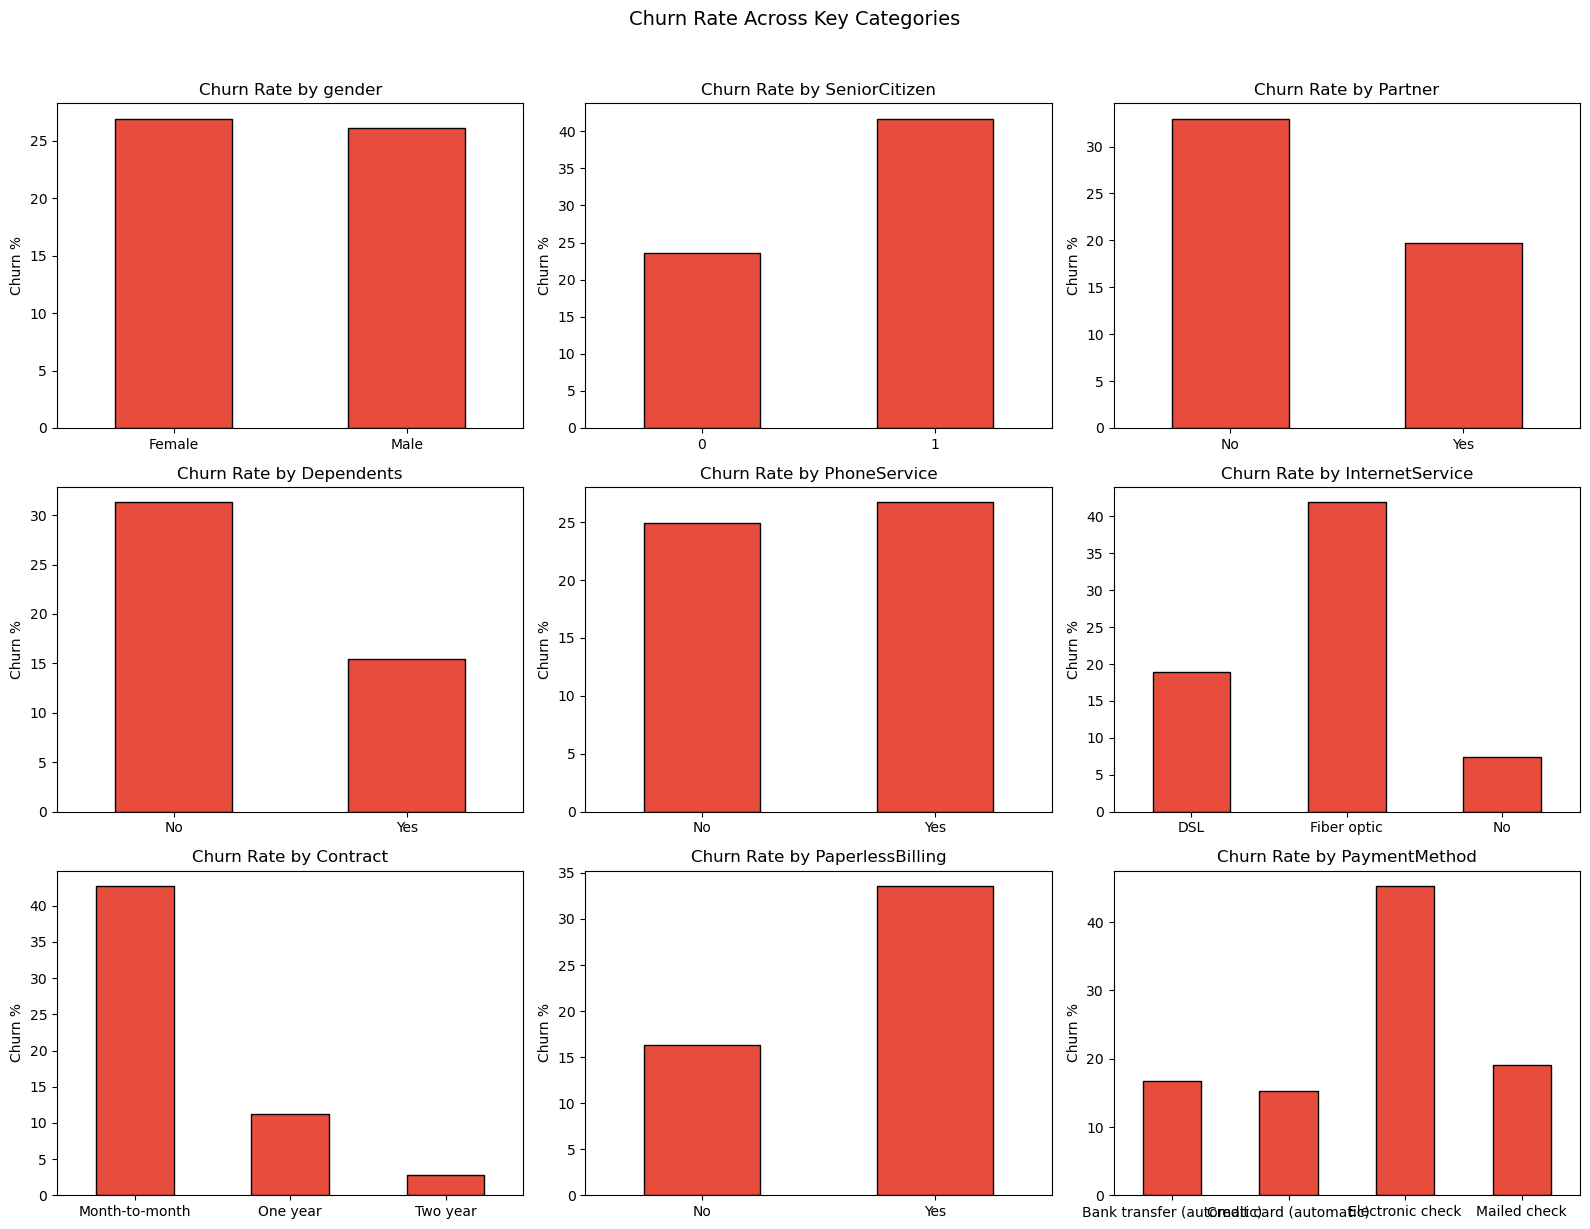

In [28]:
c_cols = ['gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'PhoneService', 'InternetService',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(c_cols):
    churn_by_col = clean_data.groupby(col)['Churn'].mean() * 100
    churn_by_col.plot(kind='bar', ax=axes[i],
                      color='#e74c3c', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn %')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x',rotation=0)

plt.suptitle('Churn Rate Across Key Categories', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
clean_data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [30]:
# Customers paying more than average relative to their tenure = higher risk
clean_data['ChargesPerMonth'] = clean_data['TotalCharges'] / (clean_data['tenure'] + 1)

# Flag new customers (first 12 months = highest churn risk)
clean_data['IsNewCustomer'] = (clean_data['tenure'] <= 12).astype(int)

# Count number of services each customer has
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

# Temporarily map Yes/No to 1/0 just for counting
clean_data['TotalServices'] = clean_data[service_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1)

print("New features created:")
print(clean_data[['ChargesPerMonth', 'IsNewCustomer', 'TotalServices']].describe())

New features created:
       ChargesPerMonth  IsNewCustomer  TotalServices
count      7043.000000    7043.000000    7043.000000
mean         61.173413       0.310379       2.941076
std          61.019723       0.462682       1.843899
min           9.183333       0.000000       0.000000
25%          26.274411       0.000000       1.000000
50%          61.150000       0.000000       3.000000
75%          84.940047       1.000000       4.000000
max        1397.475000       1.000000       7.000000


In [31]:
# --- 5.2 Encode binary columns ---
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies',
               'MultipleLines', 'PaperlessBilling']

le = LabelEncoder()
for col in binary_cols:
    clean_data[col] = le.fit_transform(clean_data[col])

# --- 5.3 One-hot encode multi-category columns ---
clean_data = pd.get_dummies(clean_data, columns=['InternetService',
                                  'Contract',
                                  'PaymentMethod'], drop_first=True)

print("\nFinal dataset shape:", clean_data.shape)
print("Columns:", clean_data.columns.tolist())


Final dataset shape: (7043, 27)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'ChargesPerMonth', 'IsNewCustomer', 'TotalServices', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [32]:
clean_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,ChargesPerMonth,IsNewCustomer,TotalServices,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,14.925000,1,1,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,53.985714,0,3,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,36.050000,1,3,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,40.016304,0,3,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,50.550000,1,1,True,False,False,False,False,True,False


In [33]:
# --- 6.1 Split features and target ---
X = clean_data.drop('Churn', axis=1)
y = clean_data['Churn']

print(f"Features: {X.shape[1]} columns")
print(f"Target distribution:\n{y.value_counts()}")

Features: 26 columns
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")


Training set: 5634 rows
Test set: 1409 rows


In [35]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, preds,
                                target_names=['Retained', 'Churned']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, proba):.4f}")
    
    results[name] = {
        'model': model,
        'predictions': preds,
        'roc_auc': roc_auc_score(y_test, proba)
    }



Model: Logistic Regression
              precision    recall  f1-score   support

    Retained       0.85      0.90      0.87      1035
     Churned       0.67      0.55      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score: 0.8473

Model: Random Forest
              precision    recall  f1-score   support

    Retained       0.83      0.89      0.86      1035
     Churned       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.8281


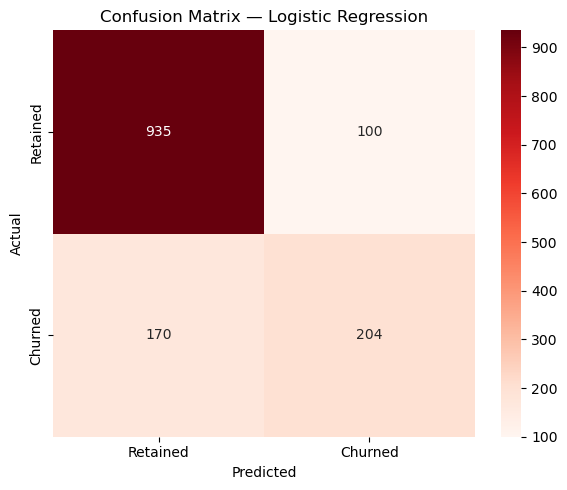

In [36]:
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_preds = results[best_model_name]['predictions']

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

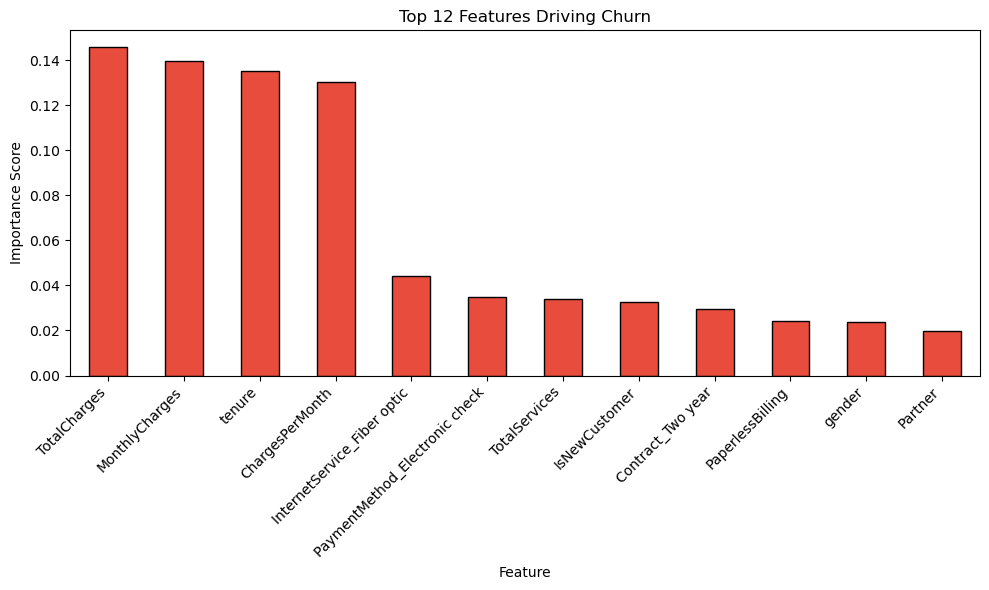


Top 5 churn drivers:
TotalCharges                   0.145957
MonthlyCharges                 0.139617
tenure                         0.135252
ChargesPerMonth                0.130375
InternetService_Fiber optic    0.044154
dtype: float64


In [37]:
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp[:12].plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Top 12 Features Driving Churn')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 churn drivers:")
print(feat_imp[:5])

In [38]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
bi_data=data.copy()


In [ ]:
bi_data['Churn_Binary'] = bi_data['Churn'].map({'Yes': 1, 'No': 0})
bi_data['IsNewCustomer'] = (bi_data['tenure'] <= 12).astype(int)

In [42]:
bi_data.to_csv('C:\imp stuff\churn_powerbi.csv', index=False)
print("Exported for Power BI:", bi_data.shape)
print(bi_data.head())

Exported for Power BI: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV St